<a href="https://colab.research.google.com/github/beyzahiz/Sentiment-Analysis-NLP/blob/main/03_tfidf_ml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("IMDB Dataset.csv")

In [36]:
import re
import string
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab') # Added to resolve the LookupError
stop_words = set(stopwords.words('english'))

def clean_text(text):
  text = text.lower()
  text = re.sub(r'<.*?>', '', text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word not in stop_words]
  return " ".join(tokens)

df['clean_review'] = df['review'].apply(clean_text)
df[['review','clean_review']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching 1 oz episode ...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [37]:
#TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)  #dataset içindeki en önemli 5000 kelimeyi kullan

X = tfidf.fit_transform(df['clean_review'])
y = df['sentiment'].map({'positive': 1, 'negative': 0})

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [38]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8874


In [39]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

[[4331  630]
 [ 496 4543]]


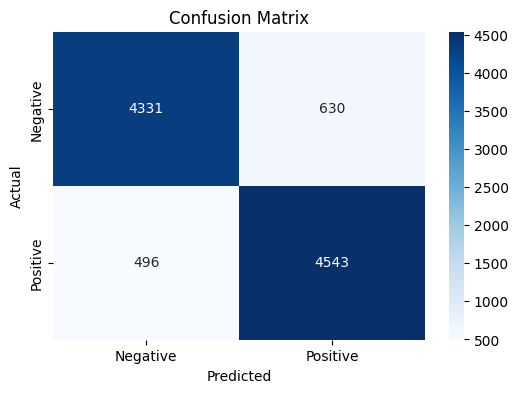

In [40]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [41]:
feature_names = tfidf.get_feature_names_out() #modelin kullandığı kelimeleri alır
coefficients = model.coef_[0] #her kelimenin modele etkisi, ağırlık

coef_df = pd.DataFrame({
    "word": feature_names,
    "weight": coefficients
})

top_positive = coef_df.sort_values("weight", ascending=False).head(20)
print(top_positive)

top_negative = coef_df.sort_values("weight").head(20)
print(top_negative)

              word    weight
1973         great  6.835588
1564     excellent  6.589135
3219       perfect  5.010407
469           best  4.923257
4930     wonderful  4.822736
220        amazing  4.586706
582      brilliant  4.390286
62             710  4.345657
1683      favorite  4.341263
2673         loved  4.287217
2115     hilarious  4.169029
1496       enjoyed  4.028465
1663     fantastic  3.823420
1495     enjoyable  3.783033
4313        superb  3.777598
2114        highly  3.756290
1184    definitely  3.692309
4514         today  3.631115
1508  entertaining  3.619585
65             810  3.570400
                word     weight
4954           worst -10.122065
4821           waste  -7.831162
388              bad  -7.138400
379            awful  -7.130948
543           boring  -6.545006
4427        terrible  -5.821993
3322            poor  -5.811140
3049         nothing  -5.607321
1394            dull  -5.070330
3323          poorly  -5.050374
4953           worse  -4.888929
2170   

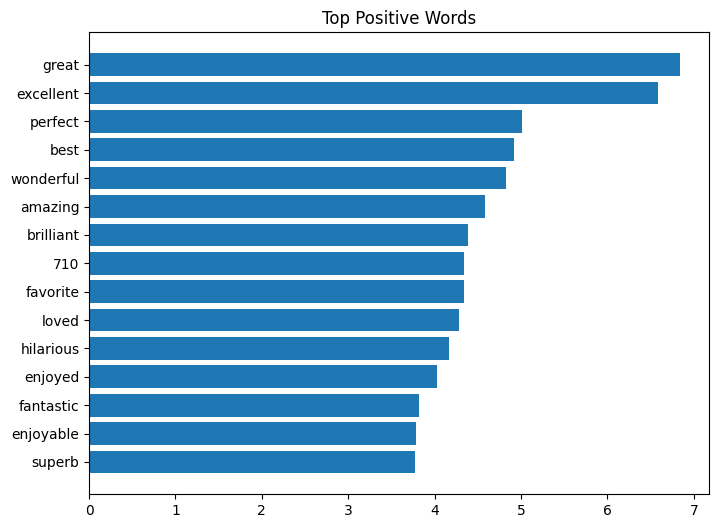

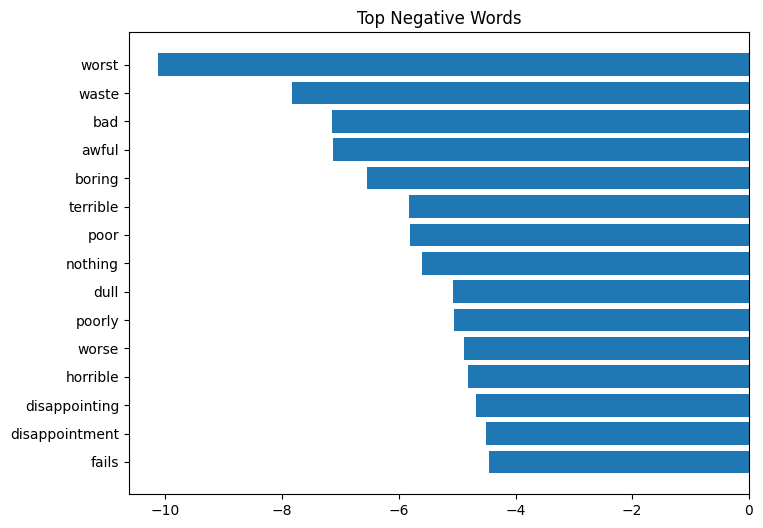

In [42]:
top_positive = coef_df.sort_values("weight", ascending=False).head(15)
plt.figure(figsize=(8, 6))
plt.barh(top_positive["word"], top_positive["weight"])
plt.title("Top Positive Words")
plt.gca().invert_yaxis()
plt.show()

top_negative = coef_df.sort_values("weight").head(15)
plt.figure(figsize=(8,6))
plt.barh(top_negative["word"], top_negative["weight"])
plt.title("Top Negative Words")
plt.gca().invert_yaxis()
plt.show()